### Short Study on Lindblad Resonances, Disk–Planet Interactions, and Planetesimal Scattering
#### Dan Chen, May 2026


#### Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import rebound
import reboundx

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
})

/opt/homebrew/lib/python3.14/site-packages/reboundx/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Lindblad resonance

In a differentially rotating disk, a planet at semi-major axis $a_p$ perturbs
disk gas via its gravitational potential. Lindblad resonance occurs where
a gas parcel's epicyclic oscillation is driven resonantly by the planet's
gravitational forcing.

The resonance condition is:

$$m(\Omega - \Omega_p) = \pm \kappa$$

where:
- $m$ is the (azimuthal) wavenumber of the perturbation
- $\Omega(r)$ is the disk gas angular velocity (Keplerian: $\Omega = \sqrt{GM/r^3}$)
- $\Omega_p$ is the planet's orbital frequency
- $\kappa$ is the epicyclic frequency; for a Keplerian disk, $\kappa = \Omega$

Note: The sign in front of $\kappa$ is $-$ if the gas is inside the planet's orbit and $+$ if the gas is outside the planet's orbit.

Rearranging: resonances occur at radii where

$$\frac{\Omega(r)}{\Omega_p} = \frac{m}{m \mp 1}$$

i.e., the gas completes $m$ orbits for every $m \mp 1$ orbits of the planet.
These are exactly mean-motion ratios — Lindblad resonances *are* the disk
analogue of MMRs between planets. 

**Inner Lindblad resonances (ILR)**: inside the planet's orbit $(r < a_p)$,
gas receives a positive torque → angular momentum flows from planet to disk.

**Outer Lindblad resonances (OLR)**: outside the planet's orbit $(r > a_p)$,
gas receives a negative torque → angular momentum flows from disk to planet.

The net torque on the planet depends on which side is greater.


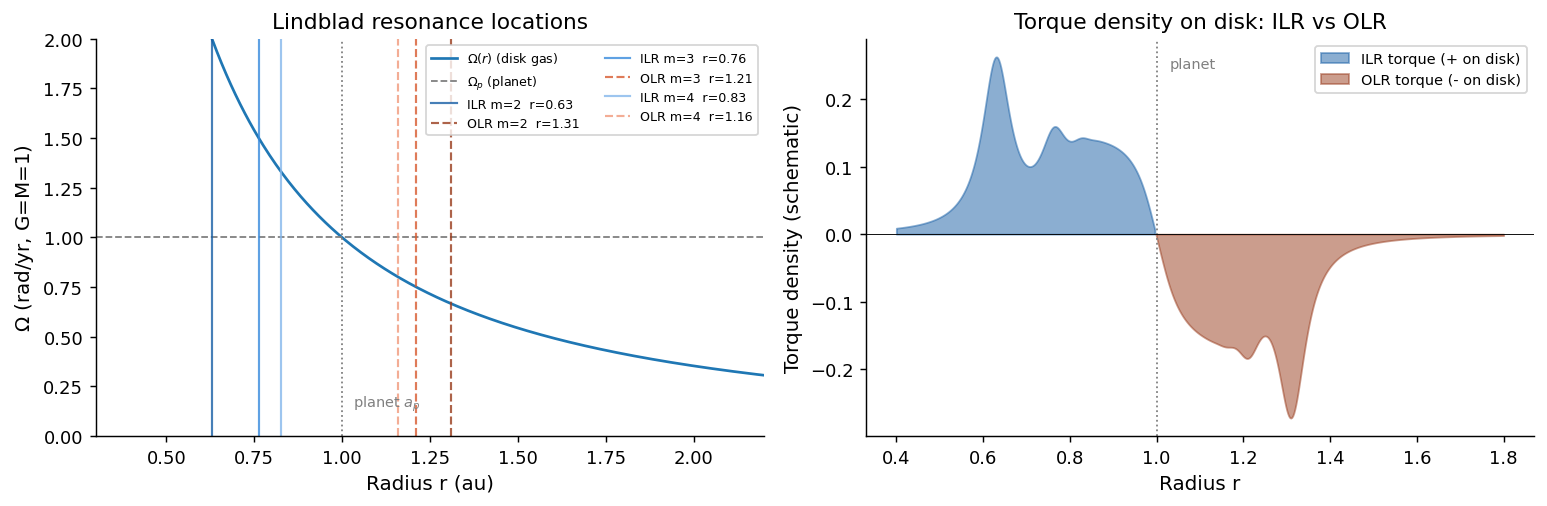

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Omega(r) and resonance locations
r = np.linspace(0.3, 2.5, 500)
Omega = r**(-3/2)           # Keplerian, G=M=1
kappa = Omega               # kappa = Omega for Keplerian

a_p = 1.0
Omega_p = a_p**(-3/2)

ax = axes[0]
ax.plot(r, Omega, "C0", label=r"$\Omega(r)$ (disk gas)")
ax.axhline(Omega_p, color="gray", ls="--", lw=1, label=r"$\Omega_p$ (planet)")
ax.axvline(a_p, color="gray", ls=":", lw=1)
ax.text(a_p + 0.03, 0.15, "planet $a_p$", fontsize=8, color="gray")

colors_ilr = ["#185FA5", "#378ADD", "#85B7EB"]
colors_olr = ["#993C1D", "#D85A30", "#F0997B"]

for i, m in enumerate([2, 3, 4]):
    # ILR: Omega/(Omega_p) = m/(m-1) → r_ILR = ((m-1)/m)^(2/3)
    r_ilr = a_p * ((m - 1) / m)**(2/3)
    r_olr = a_p * ((m + 1) / m)**(2/3)
    ax.axvline(r_ilr, color=colors_ilr[i], lw=1.2, alpha=0.8,
               label=f"ILR m={m}  r={r_ilr:.2f}")
    ax.axvline(r_olr, color=colors_olr[i], lw=1.2, alpha=0.8, ls="--",
               label=f"OLR m={m}  r={r_olr:.2f}")

ax.set_xlabel("Radius r (au)")
ax.set_ylabel(r"$\Omega$ (rad/yr, G=M=1)")
ax.set_title("Lindblad resonance locations")
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(0.3, 2.2)
ax.set_ylim(0, 2.0)

# Right: torque density schematic
ax2 = axes[1]
r2 = np.linspace(0.4, 1.8, 600)
# Approximate Goldreich & Tremaine torque density: peaks at each resonance
# We use a sum of Lorentzians, signs flipped by side
def torque_density(r, a_p, m_max=50, width=0.04):
    T = np.zeros_like(r)
    for m in range(2, m_max+1):
        r_ilr = a_p * ((m-1)/m)**(2/3)
        r_olr = a_p * ((m+1)/m)**(2/3)
        amp = 1.0 / m**2   # torque weakens with m
        T += amp * width**2 / ((r - r_ilr)**2 + width**2)   # ILR: +torque on disk
        T -= amp * width**2 / ((r - r_olr)**2 + width**2)   # OLR: -torque on disk
    return T

T = torque_density(r2, a_p)
ax2.fill_between(r2, T, 0, where=T > 0, color="#185FA5", alpha=0.5, label="ILR torque (+ on disk)")
ax2.fill_between(r2, T, 0, where=T < 0, color="#993C1D", alpha=0.5, label="OLR torque (- on disk)")
ax2.axvline(a_p, color="gray", ls=":", lw=1)
ax2.axhline(0, color="k", lw=0.5)
ax2.set_xlabel("Radius r")
ax2.set_ylabel("Torque density (schematic)")
ax2.set_title("Torque density on disk: ILR vs OLR")
ax2.legend(fontsize=8)
ax2.text(a_p + 0.03, ax2.get_ylim()[1]*0.85, "planet", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

### Torque asymmetry and Type I migration

The net torque on the planet is:

$$\Gamma_\text{net} = \Gamma_\text{OLR} + \Gamma_\text{ILR} + \Gamma_\text{corotation}$$

For a planet embedded in a smooth disk:
- $|\Gamma_\text{OLR}| > |\Gamma_\text{ILR}|$ — the outer resonances win
- The planet loses angular momentum → **inward migration** (Type I)
- Migration rate: $\dot{a}/a \approx -C \cdot (m_p/M_*)(m_p/m_\text{disk}) \cdot (a/H)^2 \cdot \Omega_p$

where $H$ is the disk scale height and $C \sim 2$–$4$ depending on disk profile.

Characteristics:
- Faster for more massive planets (until gap opens → Type II)
- Faster in denser / thinner disks
- Can reverse sign in regions of steep density/temperature gradients (planet traps)

The timescale is parametrized as $\tau_a = a / |\dot{a}|$, typically $10^4$–$10^6$ yr for Earth-to-Neptune mass planets in a MMSN disk.

### Gap opening and Type II migration

When the planet is massive enough, the torque it exerts on the disk exceeds the disk's ability to viscously refill the gap. The criterion is roughly:

$$\frac{m_p}{M_*} \gtrsim \left(\frac{H}{r}\right)^3 \cdot \frac{1}{\sqrt{\alpha_\nu}}$$

where $\alpha_\nu$ is the Shakura-Sunyaev viscosity parameter. For a typical disk
($H/r = 0.05$, $\alpha_\nu = 10^{-3}$), this gives $m_p/M_* \gtrsim 10^{-3}$
— roughly Jupiter mass.

Once a gap opens, the planet is locked to the viscous evolution of the disk (Type II migration), which is generally slower than Type I.

Below we visualize the disk surface density with and without a gap, and mark the
Lindblad resonance locations relative to the gap edges.


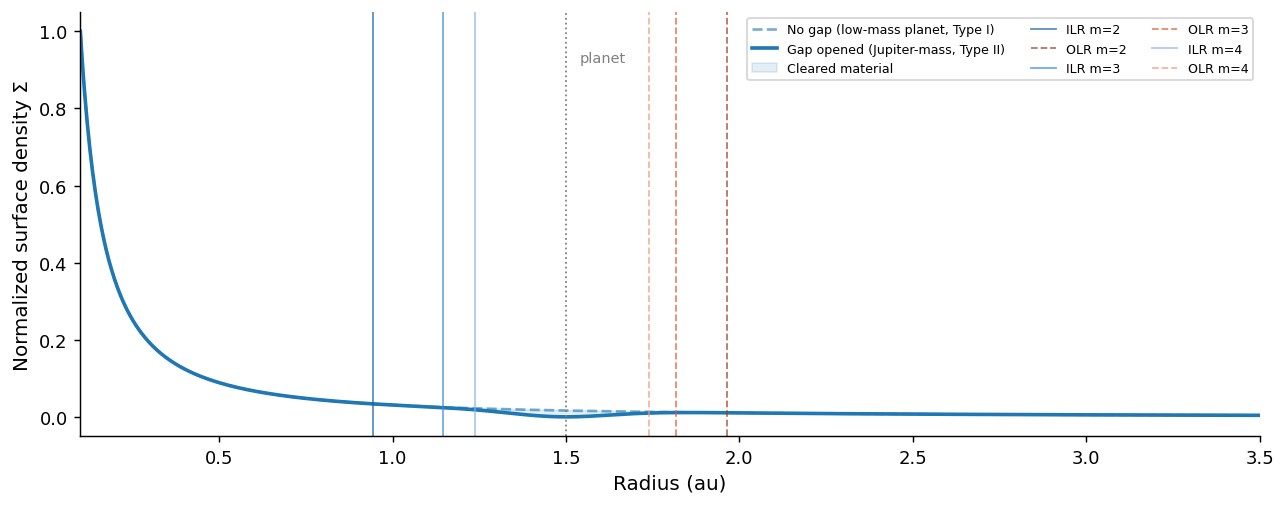

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

r_disk = np.linspace(0.1, 4.0, 1000)
Sigma0 = r_disk**(-1.5)   # power-law disk profile (MMSN-like)

a_p = 1.5
gap_width = 0.35
gap_depth = 0.05

# Gap profile: Gaussian depletion
gap = 1 - (1 - gap_depth) * np.exp(-((r_disk - a_p)**2) / (2*(gap_width/2.5)**2))
Sigma_gap = Sigma0 * gap
Sigma_no_gap = Sigma0.copy()

ax.plot(r_disk, Sigma_no_gap / Sigma_no_gap.max(), "C0", lw=1.5,
        ls="--", alpha=0.6, label="No gap (low-mass planet, Type I)")
ax.plot(r_disk, Sigma_gap / Sigma_no_gap.max(), "C0", lw=2,
        label="Gap opened (Jupiter-mass, Type II)")
ax.fill_between(r_disk, Sigma_gap / Sigma_no_gap.max(),
                Sigma_no_gap / Sigma_no_gap.max(),
                alpha=0.12, color="C0", label="Cleared material")

ax.axvline(a_p, color="gray", ls=":", lw=1)
ax.text(a_p + 0.04, 0.92, "planet", fontsize=8, color="gray")

c_ilr = ["#185FA5", "#378ADD", "#85B7EB"]
c_olr = ["#993C1D", "#D85A30", "#F0997B"]
for i, m in enumerate([2, 3, 4]):
    r_ilr = a_p * ((m-1)/m)**(2/3)
    r_olr = a_p * ((m+1)/m)**(2/3)
    ax.axvline(r_ilr, color=c_ilr[i], lw=1.0, alpha=0.7,
               label=f"ILR m={m}")
    ax.axvline(r_olr, color=c_olr[i], lw=1.0, alpha=0.7, ls="--",
               label=f"OLR m={m}")

ax.set_xlabel("Radius (au)")
ax.set_ylabel("Normalized surface density Σ")
ax.legend(fontsize=7, ncol=3, loc="upper right")
ax.set_xlim(0.1, 3.5)

plt.tight_layout()
plt.show()